# Evaluation: does simplification lose safety-critical facts?

Run `python evaluate.py` first. It writes `results/eval.csv` and `results/eval_details.json`, which this notebook reads.

**Questions we answer**
1. How much easier to read is the simplified text?
2. How often does the LLM drop or invent a critical fact on its **first try**?
3. How much does the **verify → fix → retry** loop help?
4. What kinds of facts get lost?

> ⚠️ Not medical advice. Research prototype.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/eval.csv")
details = json.load(open("../results/eval_details.json", encoding="utf-8"))
print(f"{df.drug.nunique()} drugs, {len(df)} label sections, model: {df.model.iloc[0]}")
df.head()

8 drugs, 21 label sections, model: qwen/qwen3.8-27b:free


,drug,model,section,words_before,words_after,fk_before,fk_after,hard_words_before,hard_words_after,facts_total,...,fact_recall,invented_facts,nli_coverage,nli_faithfulness,contradictions,hard_contradictions,first_try_recall,first_try_invented,retries,passed
0,ibuprofen,qwen/qwen3.8-27b:free,dosage_and_administration,67,73,27.6,3.7,16.4,8.2,6,...,1.0,0,0.750000,1.000000,0,0,1.0,0,0,True
1,ibuprofen,qwen/qwen3.8-27b:free,warnings,440,701,20.0,6.1,18.9,9.4,22,...,1.0,0,0.666667,0.830189,5,0,1.0,0,0,True
2,ibuprofen,qwen/qwen3.8-27b:free,stop_use,89,136,34.9,3.1,12.4,8.1,6,...,1.0,0,0.500000,0.937500,1,0,1.0,0,0,True
3,acetaminophen,nvidia/nemotron-3-super-120b-a12b:free,dosage_and_administration,58,67,23.9,4.4,10.3,6.0,6,...,1.0,0,0.666667,1.000000,0,0,1.0,0,0,True
4,acetaminophen,nvidia/nemotron-3-super-120b-a12b:free,warnings,230,241,11.2,7.6,20.0,17.4,14,...,1.0,0,0.764706,0.772727,3,0,1.0,0,0,True


## 1. Headline results

**Fact recall** = share of critical facts (doses, times, ages, warnings) from the original that are still in the simplified text. This is the most important number. Anything below 100% means information that could matter to a patient was lost.

We compare the LLM's **first try** with the **final** output after the verify-and-retry loop.

In [2]:
summary = pd.DataFrame({
    "First try": {
        "Fact recall (micro)": (df.first_try_recall * df.facts_total).sum() / df.facts_total.sum(),
        "Sections with 100% recall": (df.first_try_recall == 1).mean(),
        "Invented numbers (total)": df.first_try_invented.sum(),
    },
    "After verify + retry": {
        "Fact recall (micro)": df.facts_kept.sum() / df.facts_total.sum(),
        "Sections with 100% recall": (df.fact_recall == 1).mean(),
        "Invented numbers (total)": df.invented_facts.sum(),
    },
})
print(f"Sections that needed at least one retry: {(df.retries > 0).mean():.0%}")
print(f"Sections passing all hard checks at the end: {df.passed.mean():.0%}")
summary.style.format("{:.1%}", subset=pd.IndexSlice[["Fact recall (micro)", "Sections with 100% recall"], :])

Sections that needed at least one retry: 5%
Sections passing all hard checks at the end: 95%


,First try,After verify + retry
Fact recall (micro),100.0%,100.0%
Sections with 100% recall,100.0%,100.0%
Invented numbers (total),0.000000,0.000000


## 2. Readability before vs after

**Caution:** openFDA strips punctuation from bulleted lists, so many original sections look like one giant sentence. That inflates the original's Flesch-Kincaid grade and exaggerates our improvement. The **hard-words %** metric does not depend on sentence boundaries, so it is the fairer comparison. Report both, and say so in your write-up.

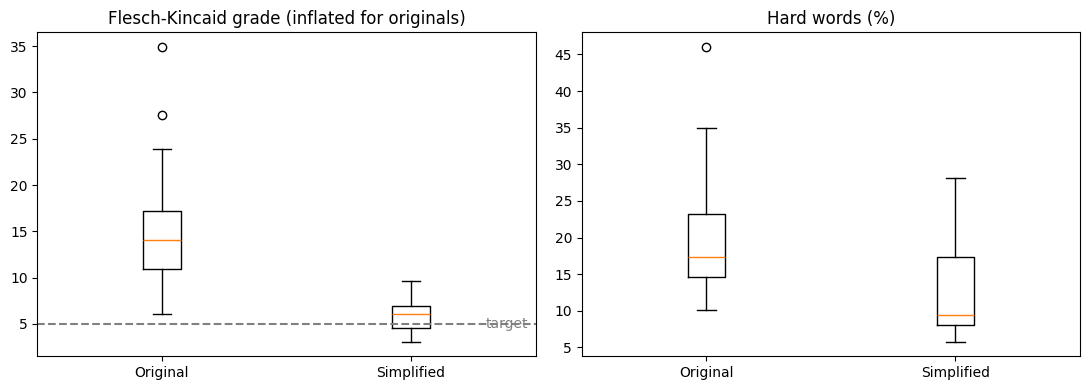

,fk_before,fk_after,hard_words_before,hard_words_after,words_before,words_after
count,21.0,21.0,21.0,21.0,21.0,21.0
mean,15.0,5.9,20.3,13.2,168.5,188.0
std,7.0,1.6,9.1,7.4,194.0,208.3
min,6.1,3.1,10.1,5.8,19.0,19.0
25%,10.9,4.6,14.6,8.1,67.0,73.0
50%,14.1,6.1,17.3,9.4,126.0,144.0
75%,17.2,6.9,23.2,17.4,161.0,167.0
max,34.9,9.6,46.0,28.1,903.0,873.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (before, after, title) in zip(axes, [
    ("fk_before", "fk_after", "Flesch-Kincaid grade (inflated for originals)"),
    ("hard_words_before", "hard_words_after", "Hard words (%)"),
]):
    ax.boxplot([df[before], df[after]], tick_labels=["Original", "Simplified"])
    ax.set_title(title)
axes[0].axhline(5, ls="--", c="gray"); axes[0].text(2.3, 5, "target", va="center", c="gray")
plt.tight_layout(); plt.show()

df[["fk_before", "fk_after", "hard_words_before", "hard_words_after", "words_before", "words_after"]].describe().round(1)

## 3. Fact recall by drug

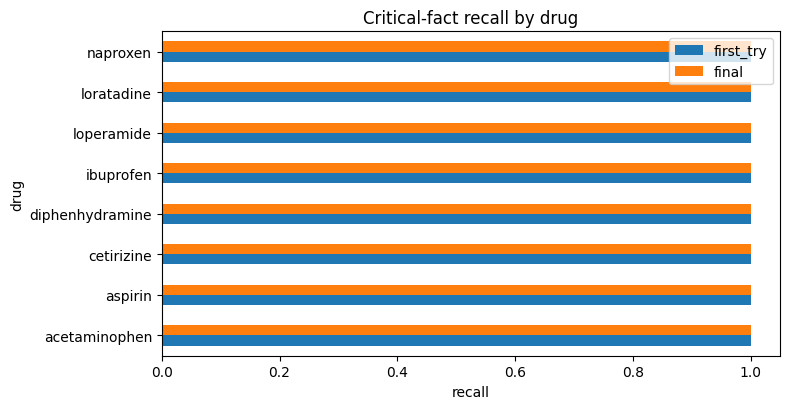

In [4]:
by_drug = df.groupby("drug").apply(
    lambda g: pd.Series({
        "first_try": (g.first_try_recall * g.facts_total).sum() / max(g.facts_total.sum(), 1),
        "final": g.facts_kept.sum() / max(g.facts_total.sum(), 1),
    }), include_groups=False,
).sort_values("final")
by_drug.plot.barh(figsize=(8, 0.4 * len(by_drug) + 1), xlim=(0, 1.05), title="Critical-fact recall by drug")
plt.xlabel("recall"); plt.tight_layout(); plt.show()

## 4. Error analysis: what gets lost or invented?

This is where the interesting findings are. Read these examples and look for patterns: are ages dropped more than doses? Do unit conversions (24 hours → 1 day) cause false alarms?

In [5]:
rows = []
for d in details:
    for f in d["missing"]:
        rows.append({"drug": d["drug"], "section": d["section"], "problem": "missing", "kind": f["kind"], "fact": f["text"]})
    for f in d["invented"]:
        rows.append({"drug": d["drug"], "section": d["section"], "problem": "invented", "kind": f["kind"], "fact": f["text"]})
errors = pd.DataFrame(rows)
if errors.empty:
    print("No missing or invented facts in the final outputs.")
else:
    display(errors.groupby(["problem", "kind"]).size().rename("count").to_frame())
    display(errors)

No missing or invented facts in the final outputs.


## 5. NLI meaning-check flags (for human review)

In [6]:
flags = pd.DataFrame([
    {"drug": d["drug"], "section": d["section"], **f} for d in details for f in d["nli_flags"]
])
if flags.empty:
    print("No NLI flags (or NLI was turned off).")
else:
    display(flags.groupby(["direction", "kind"]).size().rename("count").to_frame())
    pd.set_option("display.max_colwidth", 120)
    display(flags[["drug", "section", "direction", "kind", "sentence", "score"]].head(20))

count
direction   kind                
lost        contradiction      3
            missing           62
unsupported contradiction     10
            missing           33

,drug,section,direction,kind,sentence,score
0,ibuprofen,dosage_and_administration,lost,missing,Directions do not take more than directed the smallest effective dose should be used adults and children 12 years an...,0.125796
1,ibuprofen,warnings,unsupported,missing,The chance is higher if you are 60 years or older.,0.003439
2,ibuprofen,warnings,lost,missing,The chance is higher if you:,0.184821
3,ibuprofen,warnings,lost,missing,take more or for a longer time than directed take a blood thinning (anticoagulant) or steroid drug have had stomach ...,0.001550
4,ibuprofen,warnings,lost,missing,every day while using this product are age 60 or older take other drugs containing prescription or nonprescription N...,0.001225
5,ibuprofen,warnings,unsupported,missing,An allergic reaction means your body reacts badly to a medicine.,0.007402
6,ibuprofen,warnings,unsupported,missing,Liver cirrhosis is a liver disease.,0.223893
7,ibuprofen,warnings,unsupported,contradiction,A stroke is a brain problem.,0.996208
8,ibuprofen,warnings,unsupported,missing,A diuretic is a medicine that makes you pee more.,0.003087
9,ibuprofen,warnings,unsupported,contradiction,Stop use and ask a doctor if you have chest pain.,0.909701


## 6. Look at one example side by side

In [7]:
example = details[0]   # change the index to browse
print(example["drug"], "/", example["section"])
print("ORIGINAL:", example["original"], sep="\n", end="\n\n")
print("SIMPLIFIED:", example["simplified"], sep="\n")

ibuprofen / dosage_and_administration
ORIGINAL:
Directions do not take more than directed the smallest effective dose should be used adults and children 12 years and over: take 1 tablet every 4 to 6 hours while symptoms persist if pain or fever does not respond to 1 tablet, 2 tablets may be used do not exceed 6 tablets in 24 hours, unless directed by a doctor children under 12 years: ask a doctor

SIMPLIFIED:
- Do not take more than the label says.
- Use the smallest dose that works.
- If you are 12 years or older, take 1 tablet every 4 to 6 hours while symptoms last.
- If 1 tablet does not help your pain or fever, you may take 2 tablets.
- Do not take more than 6 tablets in 24 hours unless a doctor tells you to.
- If you are under 12 years old, ask a doctor.


## Next steps for the write-up

- **Human check of the checker.** Hand-label ~50 sections: did the fact checker and NLI flags catch every real error? That gives you precision and recall *of the verifier itself*, which is a strong result.
- **SARI.** SARI compares output against human-written simplifications. There are none for drug labels, so write simple references for ~20 sections yourself and compute SARI with the Hugging Face `evaluate` library.
- **Compare models.** Change `OPENROUTER_MODEL` in `.env`, re-run `evaluate.py`, and compare first-try recall across models.
- **Ablation.** How much does the retry loop help? (Compare the *First try* and *After verify + retry* columns above.)